In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df = pd.read_csv('gurgaon_properties_outliers_treatment.csv')

In [5]:
df.head()

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,3.0,North-East,New Property,1572.0,NaN,NaN,1,0,0,0,0,1,49.0,786.000000
1,flat,shree vardhman victoria,1.63,sector 70,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,5,3,12.0,East,Relatively New,1950.0,NaN,1161.0,0,1,0,0,0,1,43.0,650.000000
2,flat,tulip monsella,7.40,sector 53,33199.0,2229.0,Carpet area: 2229 (207.08 sq.m.),4,4,3,21.0,NaN,Under Construction,NaN,NaN,2229.0,0,0,0,0,0,1,35.0,557.250000
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,6.0,North-East,Relatively New,1370.0,NaN,NaN,0,0,0,0,0,1,49.0,456.666667
4,flat,signature andour heights,0.60,sector 71,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,600.0,NaN,514.0,0,0,0,1,0,1,59.0,300.000000


In [6]:
df.isnull().sum()

property_type             0
society                 452
price                     0
sector                    0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
facing                 1103
agePossession             0
super_built_up_area    1813
built_up_area          2065
carpet_area            1805
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score             13
area_room_ratio           0
dtype: int64

In [8]:
df[df['society'].isnull()]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
8,house,NaN,1.50,sector 5,10288.0,1458.0,Plot area 162(135.45 sq.m.)Built Up area: 210 ...,3,3,No,NaN,NaN,Old Property,NaN,210.0,NaN,0,0,0,0,0,1,0.0,486.000000
16,house,NaN,1.20,sector 48,22297.0,538.0,Plot area 50,1,4,3+,4.0,West,Old Property,NaN,535.0,NaN,0,0,0,0,0,1,8.0,538.000000
33,house,NaN,0.53,sector 7,5888.0,900.0,Built Up area: 900 (83.61 sq.m.),2,2,No,1.0,NaN,Undefined,NaN,900.0,NaN,0,0,0,0,0,1,0.0,450.000000
36,house,NaN,1.50,sector 67,8642.0,1736.0,Carpet area: 180 (150.5 sq.m.),5,3,2,2.0,NaN,New Property,NaN,NaN,180.0,0,0,0,0,0,1,0.0,347.200000
46,house,NaN,0.65,sector 105,9028.0,720.0,Plot area 80(66.89 sq.m.),3,2,1,1.0,East,Relatively New,NaN,720.0,NaN,0,0,0,1,1,1,14.0,240.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3709,house,NaN,4.75,sector 1,10556.0,4500.0,Built Up area: 4500 (418.06 sq.m.),6,7,No,4.0,NaN,Undefined,NaN,4500.0,NaN,0,0,0,0,0,1,65.0,750.000000
3711,house,NaN,1.55,sector 109,6567.0,2360.0,Built Up area: 2360 (219.25 sq.m.),3,2,No,1.0,NaN,Undefined,NaN,2360.0,NaN,0,0,0,0,0,1,0.0,786.666667
3721,house,NaN,3.50,sector 57,21605.0,1620.0,Plot area 180(150.5 sq.m.),4,4,3+,3.0,South,Old Property,NaN,1620.0,NaN,0,0,1,0,0,2,45.0,405.000000
3735,house,NaN,0.60,sector 9,10753.0,558.0,Plot area 62(51.84 sq.m.),2,2,1,1.0,North-East,Moderately Old,NaN,558.0,NaN,0,0,0,0,0,1,NaN,279.000000


In [9]:
pd.crosstab(
    df['property_type'],
    df['society'].isna(),
    normalize='index'
) * 100

society,False,True
property_type,,
flat,99.966182,0.033818
house,42.327366,57.672634


In [10]:
df['society'] = df['society'].fillna('Not Applicable')

In [13]:
df.isnull().sum()

property_type             0
society                   0
price                     0
sector                    0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
facing                 1103
agePossession             0
super_built_up_area    1813
built_up_area          2065
carpet_area            1805
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score             13
area_room_ratio           0
dtype: int64

In [16]:
# builtup area
df[df['built_up_area'].isnull()]

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,3.0,North-East,New Property,1572.0,NaN,NaN,1,0,0,0,0,1,49.0,786.000000
1,flat,shree vardhman victoria,1.63,sector 70,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,5,3,12.0,East,Relatively New,1950.0,NaN,1161.00,0,1,0,0,0,1,43.0,650.000000
2,flat,tulip monsella,7.40,sector 53,33199.0,2229.0,Carpet area: 2229 (207.08 sq.m.),4,4,3,21.0,NaN,Under Construction,NaN,NaN,2229.00,0,0,0,0,0,1,35.0,557.250000
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,6.0,North-East,Relatively New,1370.0,NaN,NaN,0,0,0,0,0,1,49.0,456.666667
4,flat,signature andour heights,0.60,sector 71,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,600.0,NaN,514.00,0,0,0,1,0,1,59.0,300.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3731,flat,m3m heights,2.50,sector 65,13600.0,1838.0,Super Built up area 1828(169.83 sq.m.),3,3,3,19.0,NaN,Under Construction,1828.0,NaN,NaN,0,0,0,0,0,1,NaN,612.666667
3733,flat,green court,0.50,sector 90,8333.0,600.0,Super Built up area 700(65.03 sq.m.)Carpet are...,2,2,1,8.0,NaN,New Property,700.0,NaN,600.00,0,0,0,0,0,1,NaN,300.000000
3734,flat,bestech park view ananda,1.45,sector 81,8734.0,1660.0,Super Built up area 1660(154.22 sq.m.)Carpet a...,3,2,3+,3.0,NaN,Relatively New,1660.0,NaN,1082.00,0,0,0,0,1,1,NaN,553.333333
3736,flat,puri the aravallis,3.87,sector 61,17200.0,2250.0,Super Built up area 2250(209.03 sq.m.)Carpet a...,3,4,3+,21.0,East,Under Construction,2250.0,NaN,1249.65,0,1,0,0,0,1,NaN,750.000000


In [23]:
all_filled_df = df[(~(df['super_built_up_area'].isnull())) & (~(df['built_up_area'].isnull())) & (~(df['carpet_area'].isnull()))]

In [27]:
super_to_builtup_ratio = (all_filled_df['super_built_up_area'] / all_filled_df['built_up_area']).median()

In [28]:
super_to_builtup_ratio

1.1045454545454545

In [29]:
carpet_to_builtup_ratio = (all_filled_df['carpet_area'] / all_filled_df['built_up_area']).median()

In [30]:
carpet_to_builtup_ratio

0.9

In [32]:
only_builtup_missing = df[(~(df['super_built_up_area'].isnull())) & ((df['built_up_area'].isnull())) & (~(df['carpet_area'].isnull()))]

In [36]:
only_builtup_missing['built_up_area'].fillna(
    round(
        (
            only_builtup_missing['super_built_up_area'] / super_to_builtup_ratio
            +
            only_builtup_missing['carpet_area'] / carpet_to_builtup_ratio
        ) / 2
    ),
    inplace=True
)

/tmp/ipykernel_16249/2107455614.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  only_builtup_missing['built_up_area'].fillna(
/tmp/ipykernel_16249/2107455614.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_builtup_missing['built_up_area'].fillna(


In [37]:
only_builtup_missing

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,shree vardhman victoria,1.63,sector 70,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,5,3,12.0,East,Relatively New,1950.0,1528.0,1161.00,0,1,0,0,0,1,43.0,650.000000
4,flat,signature andour heights,0.60,sector 71,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,600.0,557.0,514.00,0,0,0,1,0,1,59.0,300.000000
7,flat,emaar palm gardens,1.48,sector 83,7789.0,1900.0,Super Built up area 1900(176.52 sq.m.)Carpet a...,3,3,3,7.0,East,Relatively New,1900.0,1549.0,1240.04,0,1,0,0,0,1,66.0,633.333333
14,flat,shree vardhman victoria,1.80,sector 70,9230.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,4,3,2.0,South-West,New Property,1950.0,1528.0,1161.00,0,1,0,0,1,1,45.0,650.000000
74,flat,ambience creacions,4.10,sector 22,28101.0,1459.0,Super Built up area 2781(258.36 sq.m.)Carpet a...,3,3,3+,2.0,North-East,New Property,2781.0,2069.0,1459.00,0,0,0,0,0,0,119.0,486.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3718,flat,emaar palm gardens,1.75,sector 83,9210.0,1900.0,Super Built up area 1900(176.52 sq.m.)Carpet a...,3,3,3+,11.0,East,Relatively New,1900.0,1549.0,1240.04,0,1,0,0,0,1,48.0,633.333333
3725,flat,emaar mgf emerald estate,1.30,sector 65,20602.0,631.0,Super Built up area 1020(94.76 sq.m.)Carpet ar...,2,2,2,7.0,West,Relatively New,1020.0,812.0,631.00,1,0,0,0,0,1,49.0,315.500000
3733,flat,green court,0.50,sector 90,8333.0,600.0,Super Built up area 700(65.03 sq.m.)Carpet are...,2,2,1,8.0,NaN,New Property,700.0,650.0,600.00,0,0,0,0,0,1,NaN,300.000000
3734,flat,bestech park view ananda,1.45,sector 81,8734.0,1660.0,Super Built up area 1660(154.22 sq.m.)Carpet a...,3,2,3+,3.0,NaN,Relatively New,1660.0,1353.0,1082.00,0,0,0,0,1,1,NaN,553.333333


In [38]:
df.update(only_builtup_missing)

In [40]:
df.isnull().sum()

property_type             0
society                   0
price                     0
sector                    0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
facing                 1103
agePossession             0
super_built_up_area    1813
built_up_area          1636
carpet_area            1805
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score             13
area_room_ratio           0
dtype: int64

In [41]:
sud_df = df[(~(df['super_built_up_area'].isnull())) & ((df['built_up_area'].isnull())) & ((df['carpet_area'].isnull()))]

In [42]:
sud_df

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,3.0,North-East,New Property,1572.0,NaN,NaN,1,0,0,0,0,1,49.0,786.000000
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,6.0,North-East,Relatively New,1370.0,NaN,NaN,0,0,0,0,0,1,49.0,456.666667
5,flat,bptp park generations,1.50,sector 37d,9868.0,1520.0,Super Built up area 1520(141.21 sq.m.),3,2,3+,17.0,North-East,Relatively New,1520.0,NaN,NaN,0,0,0,0,0,1,42.0,506.666667
6,flat,paras dews,1.40,sector 106,6000.0,2333.0,Super Built up area 1760(163.51 sq.m.),3,4,3+,12.0,NaN,Under Construction,1760.0,NaN,NaN,1,1,0,0,1,1,55.0,777.666667
9,flat,emaar palm gardens,1.60,sector 83,8648.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,3,3+,6.0,East,Relatively New,1850.0,NaN,NaN,1,1,1,1,0,2,167.0,616.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3722,flat,raheja vedaanta,1.25,sector 108,5681.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,2,0,0.0,NaN,Relatively New,2200.0,NaN,NaN,0,0,0,0,0,2,8.0,733.333333
3727,flat,aipl zen residences,1.65,sector 70a,13074.0,1262.0,Super Built up area 1262(117.24 sq.m.),2,2,3,23.0,North-West,New Property,1262.0,NaN,NaN,0,0,0,0,0,1,NaN,631.000000
3728,flat,dlf new town heights,2.00,sector 91,6967.0,2871.0,Super Built up area 2727(253.35 sq.m.),4,4,3+,16.0,East,Moderately Old,2727.0,NaN,NaN,1,1,0,1,0,1,NaN,717.750000
3731,flat,m3m heights,2.50,sector 65,13600.0,1838.0,Super Built up area 1828(169.83 sq.m.),3,3,3,19.0,NaN,Under Construction,1828.0,NaN,NaN,0,0,0,0,0,1,NaN,612.666667


In [45]:
sud_df['built_up_area'] = sud_df['built_up_area'].fillna(
    (sud_df['super_built_up_area'] / super_to_builtup_ratio).round()
)

/tmp/ipykernel_16249/922172192.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sud_df['built_up_area'] = sud_df['built_up_area'].fillna(


In [46]:
sud_df

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,3.0,North-East,New Property,1572.0,1423.0,NaN,1,0,0,0,0,1,49.0,786.000000
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,6.0,North-East,Relatively New,1370.0,1240.0,NaN,0,0,0,0,0,1,49.0,456.666667
5,flat,bptp park generations,1.50,sector 37d,9868.0,1520.0,Super Built up area 1520(141.21 sq.m.),3,2,3+,17.0,North-East,Relatively New,1520.0,1376.0,NaN,0,0,0,0,0,1,42.0,506.666667
6,flat,paras dews,1.40,sector 106,6000.0,2333.0,Super Built up area 1760(163.51 sq.m.),3,4,3+,12.0,NaN,Under Construction,1760.0,1593.0,NaN,1,1,0,0,1,1,55.0,777.666667
9,flat,emaar palm gardens,1.60,sector 83,8648.0,1850.0,Super Built up area 1850(171.87 sq.m.),3,3,3+,6.0,East,Relatively New,1850.0,1675.0,NaN,1,1,1,1,0,2,167.0,616.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3722,flat,raheja vedaanta,1.25,sector 108,5681.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,2,0,0.0,NaN,Relatively New,2200.0,1992.0,NaN,0,0,0,0,0,2,8.0,733.333333
3727,flat,aipl zen residences,1.65,sector 70a,13074.0,1262.0,Super Built up area 1262(117.24 sq.m.),2,2,3,23.0,North-West,New Property,1262.0,1143.0,NaN,0,0,0,0,0,1,NaN,631.000000
3728,flat,dlf new town heights,2.00,sector 91,6967.0,2871.0,Super Built up area 2727(253.35 sq.m.),4,4,3+,16.0,East,Moderately Old,2727.0,2469.0,NaN,1,1,0,1,0,1,NaN,717.750000
3731,flat,m3m heights,2.50,sector 65,13600.0,1838.0,Super Built up area 1828(169.83 sq.m.),3,3,3,19.0,NaN,Under Construction,1828.0,1655.0,NaN,0,0,0,0,0,1,NaN,612.666667


In [48]:
df.update(sud_df)

In [49]:
df.isnull().sum()

property_type             0
society                   0
price                     0
sector                    0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
facing                 1103
agePossession             0
super_built_up_area    1813
built_up_area           727
carpet_area            1805
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score             13
area_room_ratio           0
dtype: int64

In [50]:
carp_df = df[((df['super_built_up_area'].isnull())) & ((df['built_up_area'].isnull())) & (~(df['carpet_area'].isnull()))]

In [51]:
carp_df

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
2,flat,tulip monsella,7.40,sector 53,33199.0,2229.0,Carpet area: 2229 (207.08 sq.m.),4,4,3,21.0,NaN,Under Construction,NaN,NaN,2229.0,0,0,0,0,0,1,35.0,557.250000
11,flat,ireo the grand arch,4.85,sector 58,16934.0,2864.0,Carpet area: 2864 (266.07 sq.m.),4,5,3,23.0,North-West,Relatively New,NaN,NaN,2864.0,1,1,0,1,1,2,49.0,716.000000
21,flat,smart world orchard,2.57,sector 61,15766.0,1630.0,Carpet area: 1630 (151.43 sq.m.),3,3,2,3.0,North-East,Under Construction,NaN,NaN,1630.0,1,0,0,0,0,1,0.0,543.333333
23,flat,vatika inxt floors,1.25,sector 82a,8333.0,1500.0,Carpet area: 1500 (139.35 sq.m.),3,2,3,2.0,North,Relatively New,NaN,NaN,1500.0,1,0,0,1,0,2,94.0,500.000000
26,flat,satya the hermitage,0.93,sector 103,6404.0,1452.0,Carpet area: 1452 (134.9 sq.m.),2,3,3,3.0,East,Relatively New,NaN,NaN,1452.0,0,1,0,0,0,2,90.0,726.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3702,flat,central park flower valley,2.50,sector-33 sohna,13270.0,1884.0,Carpet area: 1884 (175.03 sq.m.),3,3,2,1.0,NaN,Undefined,NaN,NaN,1884.0,0,0,0,0,0,1,24.0,628.000000
3706,flat,apartment,0.75,sector 92,4687.0,1600.0,Carpet area: 1600 (148.64 sq.m.),3,4,3,2.0,East,Moderately Old,NaN,NaN,1600.0,1,0,0,0,0,1,45.0,533.333333
3717,flat,smart world orchard,1.65,sector 61,13750.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,1.0,NaN,Under Construction,NaN,NaN,1200.0,1,0,0,0,0,1,9.0,600.000000
3723,flat,godrej oasis,1.15,sector 88a,9856.0,1167.0,Carpet area: 108.4,2,2,1,12.0,NaN,New Property,NaN,NaN,108.4,1,0,0,0,0,1,58.0,583.500000


In [54]:
carp_df['built_up_area'] = carp_df['built_up_area'].fillna(
    (carp_df['carpet_area'] / carpet_to_builtup_ratio).round()
)

/tmp/ipykernel_16249/3733824434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carp_df['built_up_area'] = carp_df['built_up_area'].fillna(


In [56]:
df.update(carp_df)

In [60]:
df.isnull().sum()

property_type             0
society                   0
price                     0
sector                    0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 19
agePossession             0
super_built_up_area    1813
built_up_area             0
carpet_area            1805
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score             13
area_room_ratio           0
dtype: int64

In [58]:
df = df.drop('facing', axis = 1)

<Axes: xlabel='built_up_area', ylabel='price'>

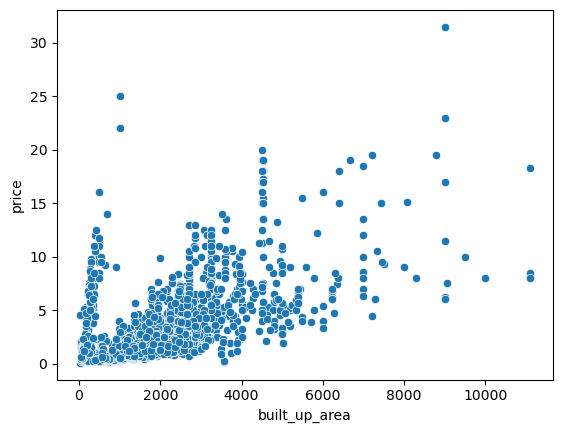

In [62]:
sns.scatterplot(data = df,x = 'built_up_area',y = 'price')

In [63]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [64]:
anamoly_df.sample(5)

,price,area,built_up_area
1013,4.60,1426.0,1426.0
3560,4.00,1836.0,1836.0
1475,3.30,1242.0,1242.0
978,6.15,2250.0,270.0
3023,2.58,1458.0,1444.0


In [65]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [66]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

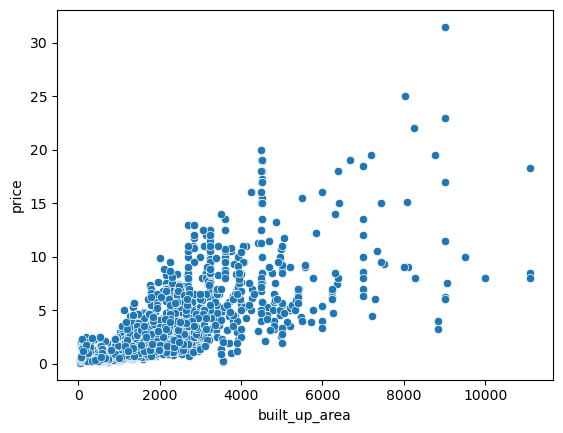

In [67]:
sns.scatterplot(data = df,x = 'built_up_area',y = 'price')

In [68]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [69]:
df[df['floorNum'].isnull()]

,property_type,society,price,sector,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
8,house,Not Applicable,1.50,sector 5,10288.0,3,3,No,NaN,Old Property,210.0,0,0,0,0,0,1,0.0
56,house,Not Applicable,1.45,sector 25,2984.0,3,3,1,NaN,Old Property,540.0,0,0,0,0,0,1,9.0
653,house,Not Applicable,1.10,sector 61,8148.0,2,2,1,NaN,Old Property,150.0,0,0,0,0,1,1,0.0
996,house,ansal sushant lok,10.50,sector 43,27911.0,4,4,2,NaN,Old Property,3762.0,0,1,0,0,0,1,174.0
1035,house,dlf new town heights,2.47,sector 86,7718.0,4,4,3+,NaN,Moderately Old,2800.0,0,1,0,1,0,2,45.0
1118,house,Not Applicable,0.65,sector 3a,11111.0,4,2,2,NaN,Moderately Old,585.0,0,0,0,0,0,1,0.0
1144,house,Not Applicable,5.60,sector 23,17284.0,8,6,3+,NaN,Moderately Old,3240.0,1,1,1,1,0,1,119.0
1475,house,ansal sushant lok plots,3.30,sector 43,26570.0,1,1,No,NaN,Under Construction,1242.0,0,0,0,0,0,1,120.0
1494,house,emaar mgf marbella,9.00,sector 66,21251.0,4,4,3+,NaN,Relatively New,5200.0,0,1,1,1,0,2,38.0
2180,house,vipul tatvam villa,8.50,sector 48,26235.0,4,4,1,NaN,Relatively New,3240.0,0,0,0,0,0,1,0.0


In [70]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [71]:
df['floorNum'].fillna(2.0,inplace=True)

/tmp/ipykernel_16249/15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [72]:
df.isnull().sum()

property_type       0
society             0
price               0
sector              0
price_per_sqft      0
bedRoom             0
bathroom            0
balcony             0
floorNum            0
agePossession       0
built_up_area       0
study room          0
servant room        0
store room          0
pooja room          0
others              0
furnishing_type     0
luxury_score       13
dtype: int64

In [73]:
#agePossession
df['agePossession'].value_counts()

agePossession
Relatively New        1645
New Property           598
Moderately Old         567
Undefined              332
Old Property           314
Under Construction     283
Name: count, dtype: int64

In [74]:
df[df['agePossession'] == 'Undefined']

,property_type,society,price,sector,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
20,flat,breeze global heights,0.40,sector 33,6421.0,2,2,2,4.0,Undefined,623.0,0,0,0,0,0,1,0.0
33,house,Not Applicable,0.53,sector 7,5888.0,2,2,No,1.0,Undefined,900.0,0,0,0,0,0,1,0.0
35,flat,krisumi waterfall residences,2.30,sector 36a,15551.0,2,2,2,23.0,Undefined,1479.0,0,0,0,0,0,1,58.0
51,house,Not Applicable,4.25,sector 10a,17955.0,4,3,2,1.0,Undefined,2367.0,0,0,0,0,0,1,0.0
76,flat,residency grand,5.00,sector 52,9615.0,5,5,3+,2.0,Undefined,5200.0,0,0,0,0,0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3697,flat,shree vardhman victoria,1.75,sector 70,8974.0,3,5,0,0.0,Undefined,1950.0,0,0,0,0,0,1,21.0
3702,flat,central park flower valley,2.50,sector-33 sohna,13270.0,3,3,2,1.0,Undefined,2093.0,0,0,0,0,0,1,24.0
3709,house,Not Applicable,4.75,sector 1,10556.0,6,7,No,4.0,Undefined,4500.0,0,0,0,0,0,1,65.0
3711,house,Not Applicable,1.55,sector 109,6567.0,3,2,No,1.0,Undefined,2360.0,0,0,0,0,0,1,0.0


In [75]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [76]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [77]:
df['agePossession'].value_counts()

agePossession
Relatively New        1781
New Property           627
Moderately Old         618
Old Property           345
Under Construction     299
Undefined               69
Name: count, dtype: int64

In [78]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [79]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [80]:
df['agePossession'].value_counts()

agePossession
Relatively New        1798
Moderately Old         670
New Property           627
Old Property           345
Under Construction     299
Name: count, dtype: int64

In [81]:
df.isnull().sum()

property_type       0
society             0
price               0
sector              0
price_per_sqft      0
bedRoom             0
bathroom            0
balcony             0
floorNum            0
agePossession       0
built_up_area       0
study room          0
servant room        0
store room          0
pooja room          0
others              0
furnishing_type     0
luxury_score       13
dtype: int64

In [85]:
df[df['luxury_score'].isnull()][['price','furnishing_type']]

,price,furnishing_type
3726,3.00,1
3727,1.65,1
3728,2.00,1
3729,6.00,2
3730,6.00,1
3731,2.50,1
3732,1.25,1
3733,0.50,1
3734,1.45,1
3735,0.60,1


In [89]:
df['luxury_score'] = df['luxury_score'].fillna(0)

In [90]:
df.isnull().sum()

property_type      0
society            0
price              0
sector             0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [91]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [92]:
df.shape

(3739, 18)